# Stage-1 Training Loss Curve

讀取 `stage1_training/<run>/logging.jsonl`（ms-swift 訓練輸出）並繪製 loss / token_acc / learning_rate 曲線，可同時比較多個 run。

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# --- validated categorical palette (fixed order, never cycled) ---
SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
INK_MUTED = "#898781"
GRID = "#e1e0d9"
BASELINE = "#c3c2b7"
CATEGORICAL = ["#2a78d6", "#008300", "#e87ba4", "#eda100", "#1baf7a", "#eb6834", "#4a3aa7", "#e34948"]

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_PRIMARY,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "text.color": INK_PRIMARY,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [2]:
# --- config ---
STAGE1_DIR = Path("stage1_training")  # 相對於此 notebook 的位置

# 只畫指定 run；留空 [] 代表自動抓 STAGE1_DIR 底下所有含 logging.jsonl 的資料夾
RUN_NAMES: list[str] = []

# loss 逐 step 抖動較大，用 rolling mean 疊加平滑線（仿 TensorBoard smoothing）
SMOOTH_WINDOW = 10

In [3]:
def load_run(log_path: Path) -> pd.DataFrame:
    """Parse a ms-swift logging.jsonl into a per-step metrics DataFrame."""
    rows = []
    with log_path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)
            step_field = rec.get("global_step/max_steps")
            if "loss" not in rec or step_field is None:
                continue  # 初始化那一行（model_parameter_info 等）沒有 loss，略過
            step_str, max_step_str = step_field.split("/")
            rows.append({
                "step": int(step_str),
                "max_steps": int(max_step_str),
                "epoch": rec.get("epoch"),
                "loss": rec.get("loss"),
                "grad_norm": rec.get("grad_norm"),
                "learning_rate": rec.get("learning_rate"),
                "token_acc": rec.get("token_acc"),
            })
    return pd.DataFrame(rows)


def discover_runs(stage1_dir: Path, run_names: list[str]) -> dict[str, Path]:
    if run_names:
        return {name: stage1_dir / name / "logging.jsonl" for name in run_names}
    return {
        p.parent.name: p
        for p in sorted(stage1_dir.glob("*/logging.jsonl"))
    }

In [4]:
runs = discover_runs(STAGE1_DIR, RUN_NAMES)

dfs: dict[str, pd.DataFrame] = {}
for name, log_path in runs.items():
    if not log_path.exists():
        print(f"[skip] {name}: 找不到 {log_path}")
        continue
    df = load_run(log_path)
    if df.empty:
        print(f"[skip] {name}: 尚未有任何 step 記錄（訓練可能還沒開始或剛啟動）")
        continue
    dfs[name] = df
    last = df.iloc[-1]
    print(f"{name}: step {int(last.step)}/{int(last.max_steps)}, loss={last.loss:.4f}, token_acc={last.token_acc:.4f}")

if len(dfs) > len(CATEGORICAL):
    print(f"\n警告: {len(dfs)} 個 run 超過調色盤的 {len(CATEGORICAL)} 色上限，後面的 run 會重複顏色。")

[skip] v0-20260718-150633: 尚未有任何 step 記錄（訓練可能還沒開始或剛啟動）
[skip] v1-20260718-155309: 尚未有任何 step 記錄（訓練可能還沒開始或剛啟動）
v2-20260718-162012: step 35/3750, loss=0.0795, token_acc=0.9689
v3-20260718-163016: step 260/939, loss=0.0526, token_acc=0.9774
v4-20260719-004626: step 35/939, loss=0.0825, token_acc=0.9683
v5-20260719-005455: step 1895/3750, loss=0.0349, token_acc=0.9839


## Loss Curve

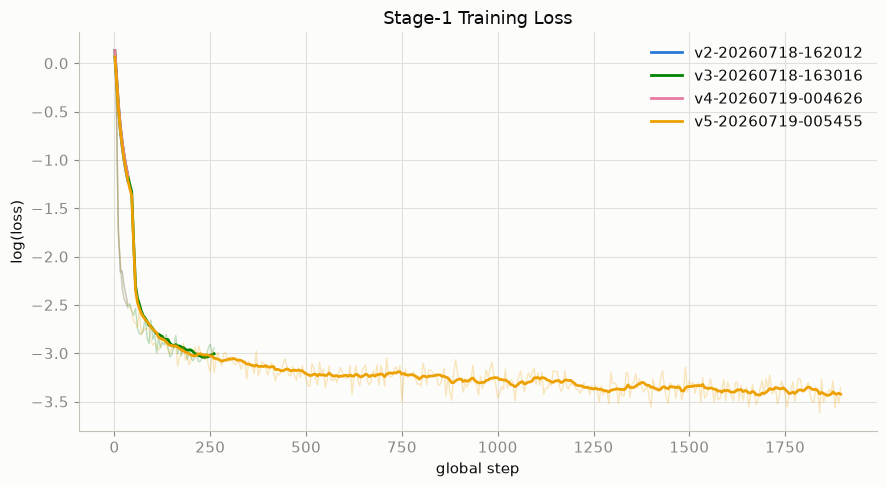

In [8]:
import numpy as np
fig, ax = plt.subplots(figsize=(9, 5))

for i, (name, df) in enumerate(dfs.items()):
    color = CATEGORICAL[i % len(CATEGORICAL)]
    ax.plot(df["step"], np.log(df["loss"]), color=color, linewidth=1, alpha=0.25)
    smoothed = df["loss"].rolling(SMOOTH_WINDOW, min_periods=1).mean()
    ax.plot(df["step"], np.log(smoothed), color=color, linewidth=2, label=name)

ax.set_xlabel("global step")
ax.set_ylabel("log(loss)")
ax.set_title("Stage-1 Training Loss")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## Token Accuracy & Learning Rate

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

for i, (name, df) in enumerate(dfs.items()):
    color = CATEGORICAL[i % len(CATEGORICAL)]
    smoothed_acc = df["token_acc"].rolling(SMOOTH_WINDOW, min_periods=1).mean()
    ax1.plot(df["step"], df["token_acc"], color=color, linewidth=1, alpha=0.25)
    ax1.plot(df["step"], smoothed_acc, color=color, linewidth=2, label=name)
    ax2.plot(df["step"], df["learning_rate"], color=color, linewidth=2, label=name)

ax1.set_xlabel("global step")
ax1.set_ylabel("token_acc")
ax1.set_title("Token Accuracy")
ax1.legend(frameon=False)

ax2.set_xlabel("global step")
ax2.set_ylabel("learning_rate")
ax2.set_title("LR Schedule")
ax2.legend(frameon=False)

fig.tight_layout()
plt.show()